IDENTIFIED TRIPLE-POINT(S): {'United Kingdom'}


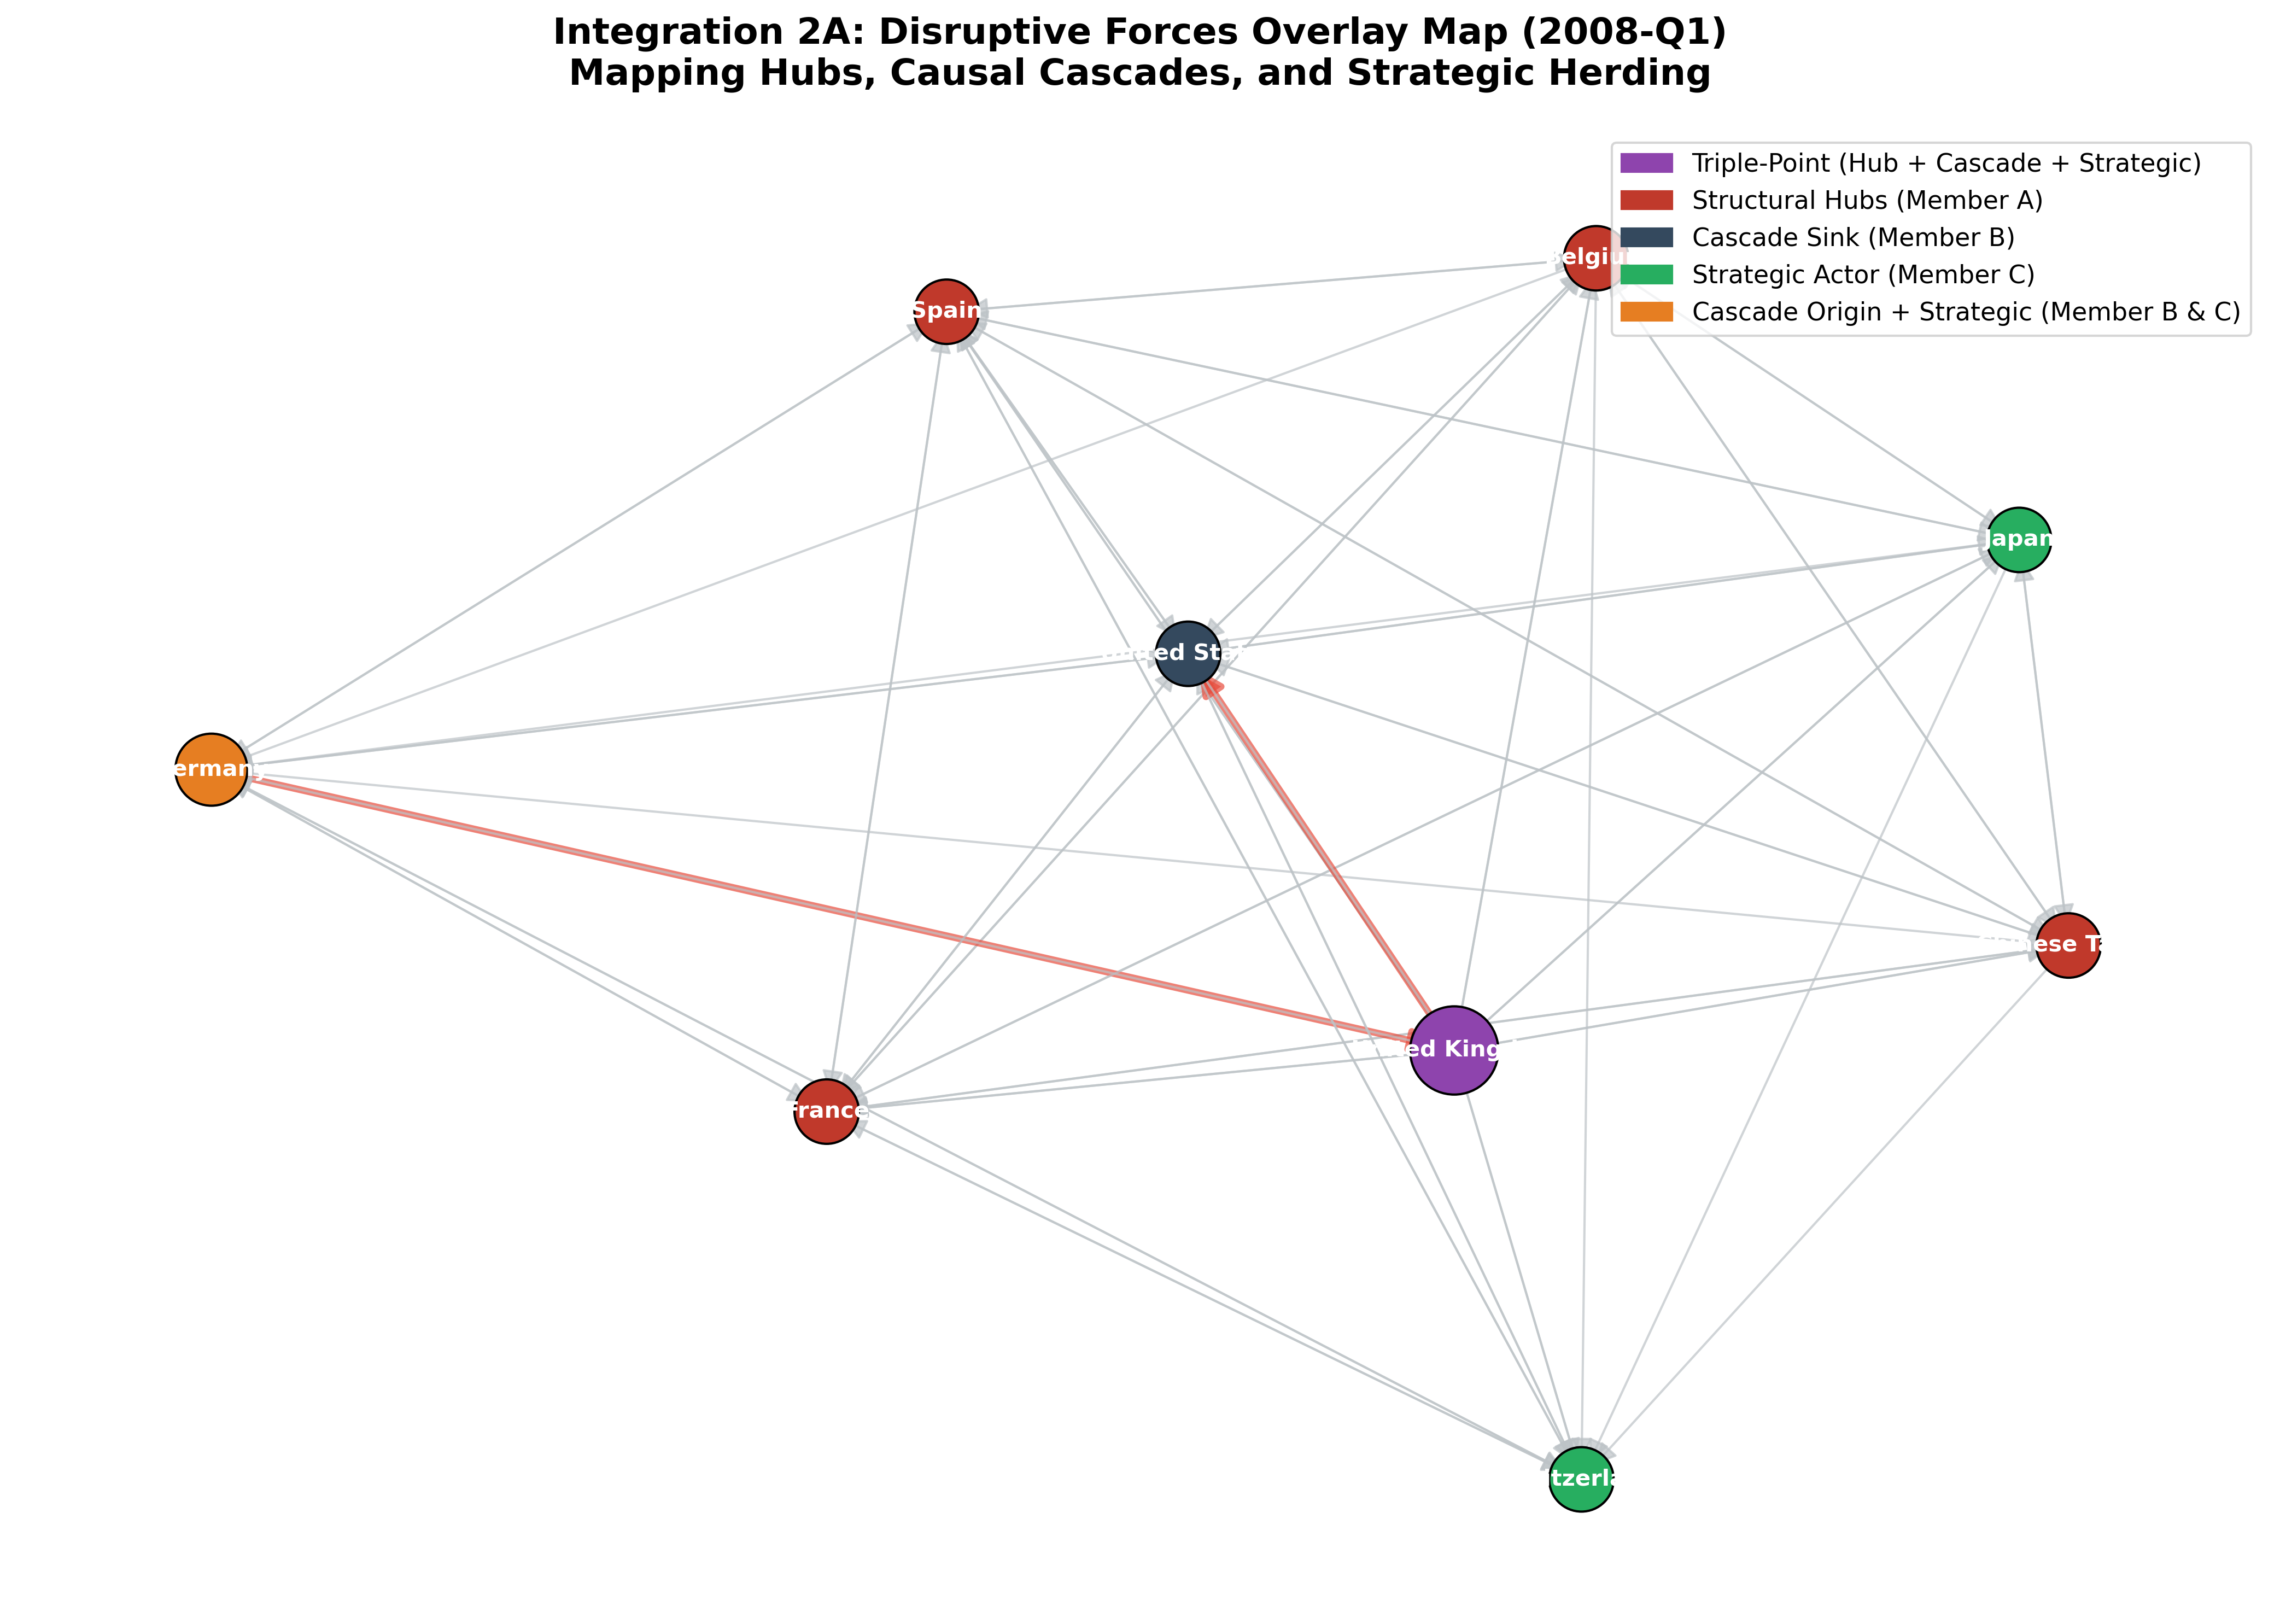

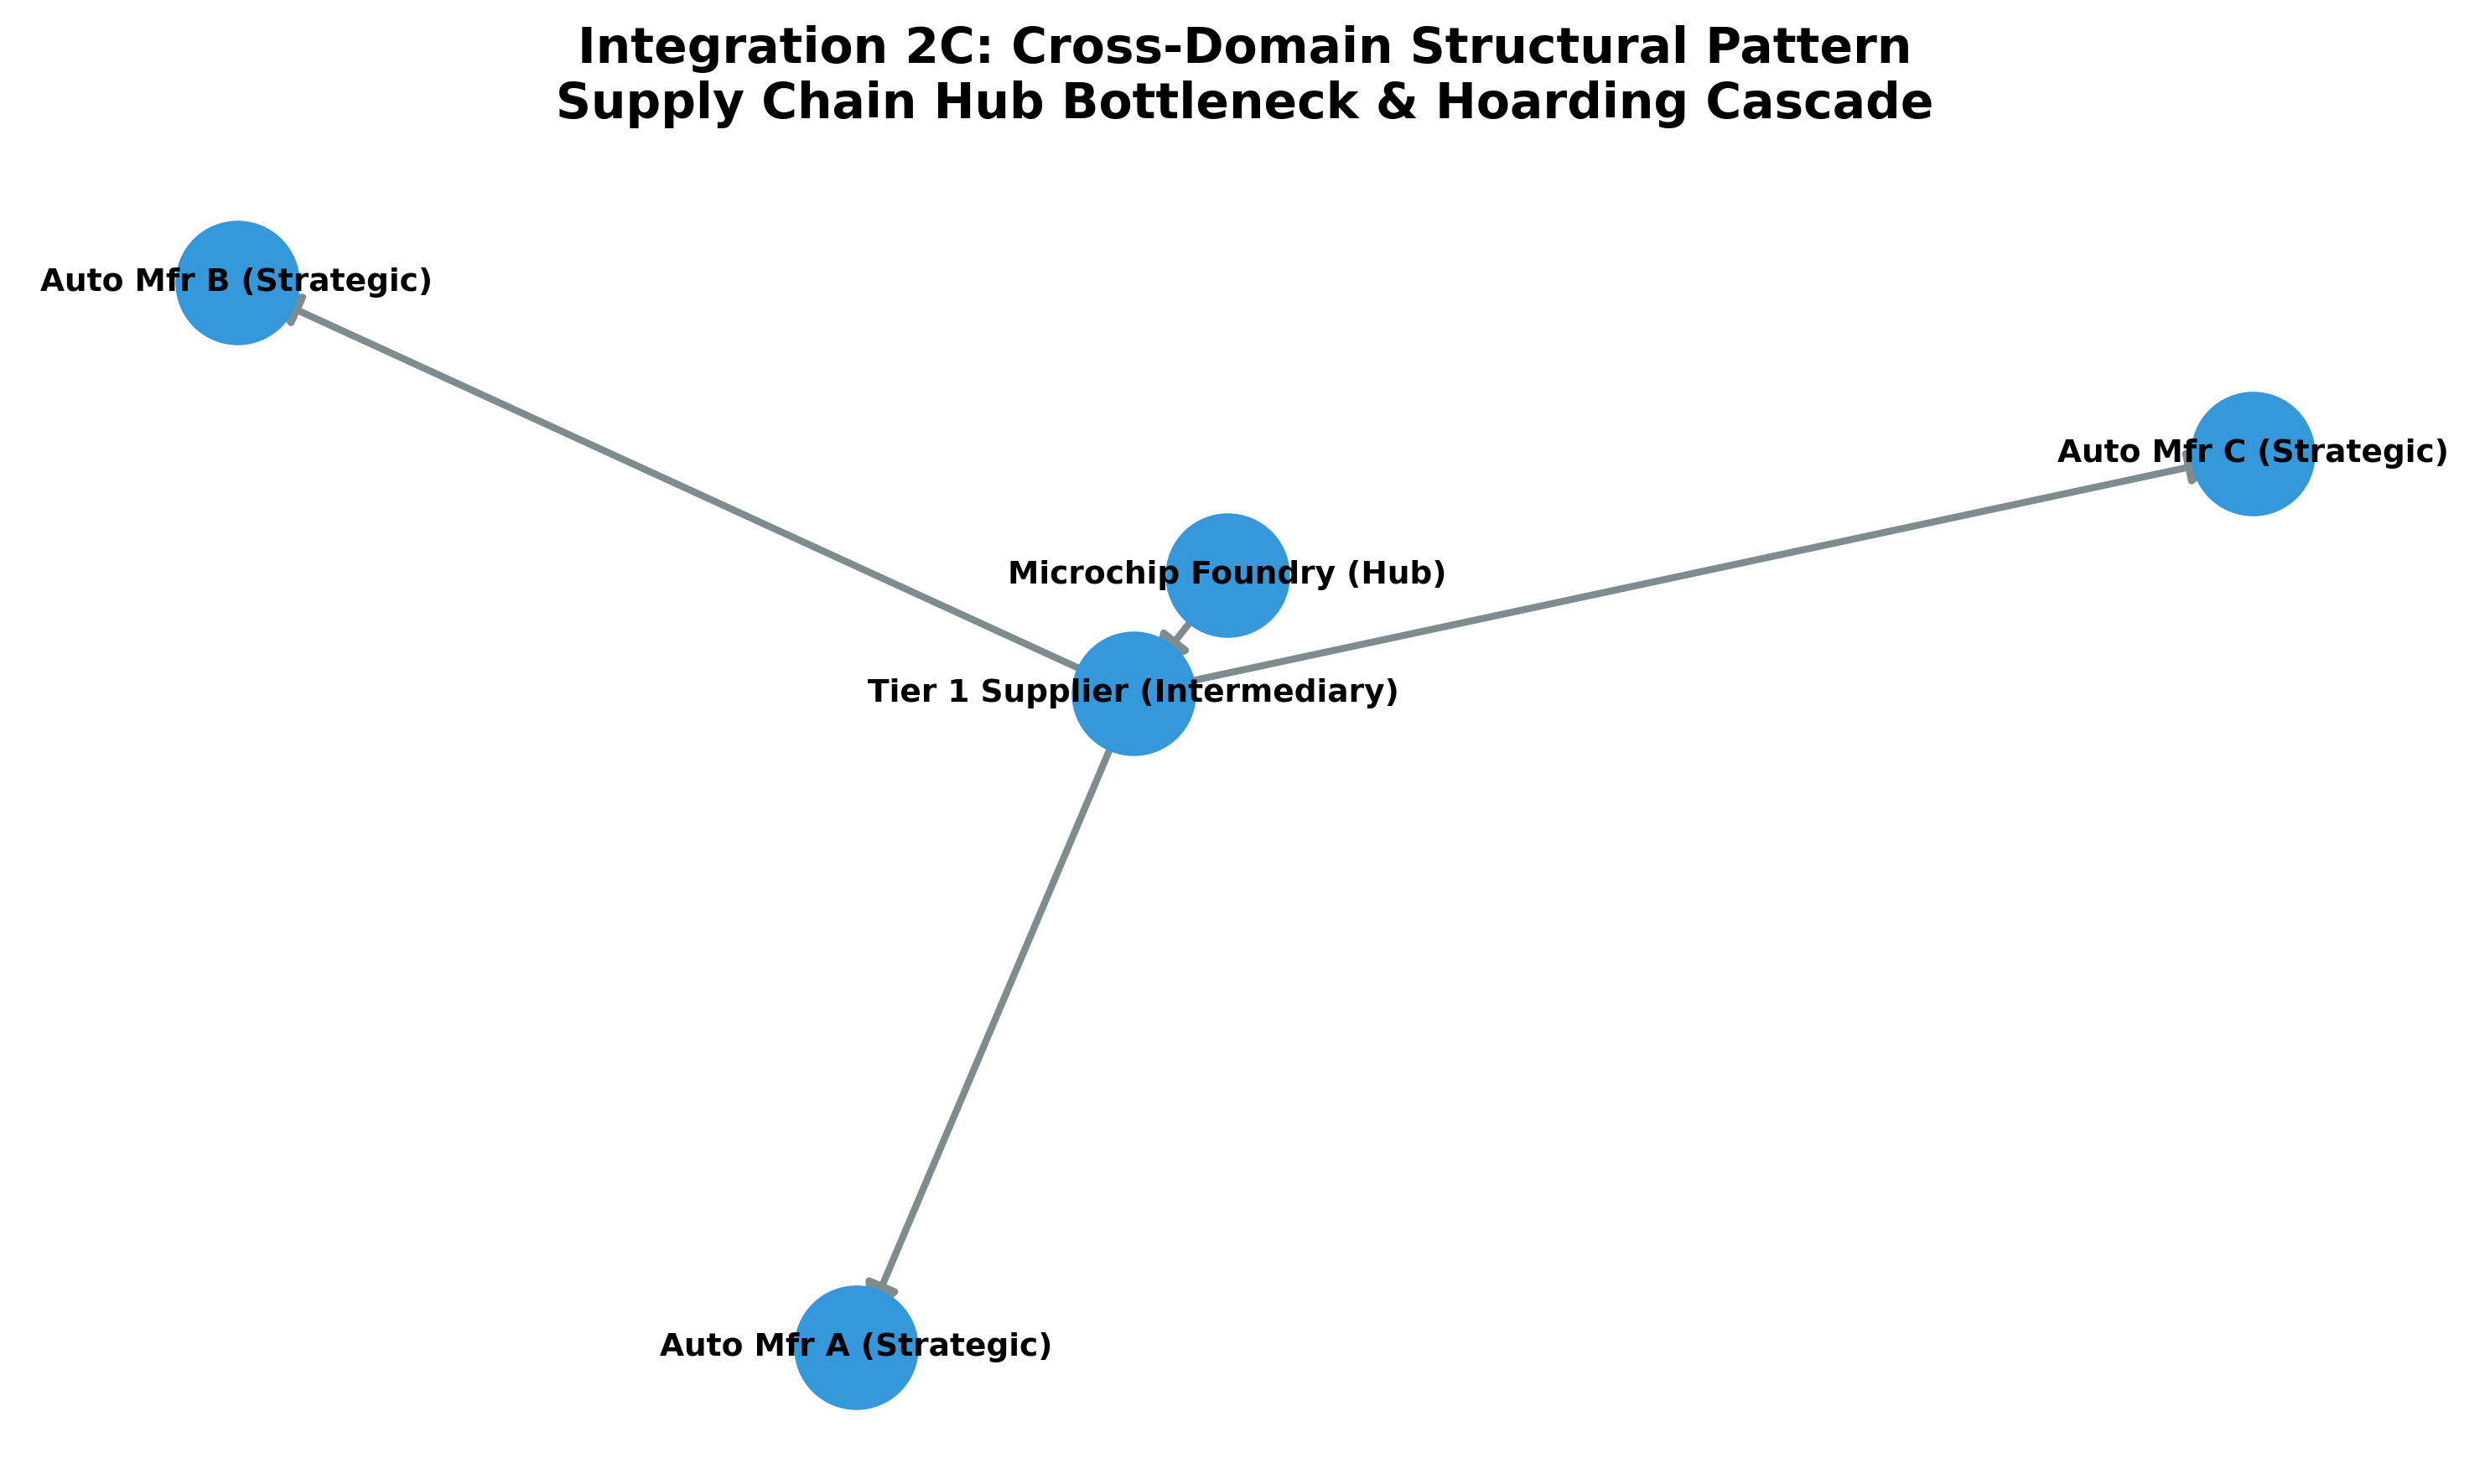

--- Integration Visualizations Generated ---


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import matplotlib.patches as mpatches

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load the positive edges dataset
df = pd.read_csv(PROCESSED_DIR / "bis_cbs_network_2007_2010_positive_edges.csv")
df_2008q1 = df[df['period'] == '2008-Q1']

# -------------------------------------------------------------
# 2A: The Overlay Map (Finding the Triple-Points)
# -------------------------------------------------------------
# Define the nodes based on our Step 1 findings
hubs = {'France', 'United Kingdom', 'Belgium', 'Spain', 'Chinese Taipei'}
cascade_path = {'Germany', 'United Kingdom', 'United States'}
strategic_actors = {'France', 'Germany', 'Switzerland', 'Japan', 'United Kingdom'}

# Identify the Triple-Point (Intersection of all three sets)
triple_points = hubs.intersection(cascade_path).intersection(strategic_actors)
print(f"IDENTIFIED TRIPLE-POINT(S): {triple_points}")

# Combine all nodes of interest
nodes_of_interest = hubs.union(cascade_path).union(strategic_actors)

# Filter the dataframe to only include edges between these key nodes to keep the diagram readable
df_sub = df_2008q1[
    (df_2008q1['Reporting country'].isin(nodes_of_interest)) & 
    (df_2008q1['Counterparty country'].isin(nodes_of_interest))
]

# Build the directed subgraph
G_overlay = nx.from_pandas_edgelist(
    df_sub, 'Reporting country', 'Counterparty country', 
    edge_attr='claim_value_usd_millions', create_using=nx.DiGraph()
)

plt.figure(figsize=(14, 10), dpi=300)
pos = nx.spring_layout(G_overlay, k=0.8, seed=42)

# Custom node coloring logic
node_colors = []
node_sizes = []
for node in G_overlay.nodes():
    if node in triple_points:
        node_colors.append('#8e44ad') # Purple for Triple-Point
        node_sizes.append(1500)
    elif node in cascade_path and node in strategic_actors:
        node_colors.append('#e67e22') # Orange for Cascade + Strategic
        node_sizes.append(1000)
    elif node in hubs:
        node_colors.append('#c0392b') # Red for Hubs
        node_sizes.append(800)
    elif node in strategic_actors:
        node_colors.append('#27ae60') # Green for Strategic only
        node_sizes.append(800)
    else:
        node_colors.append('#34495e') # Dark blue for others (e.g., US)
        node_sizes.append(800)

# Draw edges - highlight the specific cascade path
edge_colors = []
edge_widths = []
for u, v in G_overlay.edges():
    if (u == 'Germany' and v == 'United Kingdom') or (u == 'United Kingdom' and v == 'United States'):
        edge_colors.append('#e74c3c') # Red for Cascade Path
        edge_widths.append(3.0)
    else:
        edge_colors.append('#bdc3c7')
        edge_widths.append(1.0)

nx.draw_networkx_edges(G_overlay, pos, edge_color=edge_colors, width=edge_widths, arrowsize=20, alpha=0.7)
nx.draw_networkx_nodes(G_overlay, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
nx.draw_networkx_labels(G_overlay, pos, font_size=10, font_weight='bold', font_color='white')

# Create custom legend
legend_handles = [
    mpatches.Patch(color='#8e44ad', label='Triple-Point (Hub + Cascade + Strategic)'),
    mpatches.Patch(color='#c0392b', label='Structural Hubs (Member A)'),
    mpatches.Patch(color='#34495e', label='Cascade Sink (Member B)'),
    mpatches.Patch(color='#27ae60', label='Strategic Actor (Member C)'),
    mpatches.Patch(color='#e67e22', label='Cascade Origin + Strategic (Member B & C)'),
]
plt.legend(handles=legend_handles, loc='upper right', fontsize=11, frameon=True)

plt.title('Integration 2A: Disruptive Forces Overlay Map (2008-Q1)\nMapping Hubs, Causal Cascades, and Strategic Herding', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_2a_overlay_map.png", bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# 2C: Cross-Domain Confirmation (Supply Chain Secondary Dashboard)
# -------------------------------------------------------------
# Creating a simplified generic Supply Chain network to mirror the banking topology
G_sc = nx.DiGraph()

sc_nodes = ['Microchip Foundry (Hub)', 'Tier 1 Supplier (Intermediary)', 
            'Auto Mfr A (Strategic)', 'Auto Mfr B (Strategic)', 'Auto Mfr C (Strategic)']

G_sc.add_edges_from([
    ('Microchip Foundry (Hub)', 'Tier 1 Supplier (Intermediary)'),
    ('Tier 1 Supplier (Intermediary)', 'Auto Mfr A (Strategic)'),
    ('Tier 1 Supplier (Intermediary)', 'Auto Mfr B (Strategic)'),
    ('Tier 1 Supplier (Intermediary)', 'Auto Mfr C (Strategic)'),
])

plt.figure(figsize=(10, 6), dpi=300)
pos_sc = nx.spring_layout(G_sc, seed=42)

nx.draw_networkx_nodes(G_sc, pos_sc, node_size=1200, node_color='#3498db')
nx.draw_networkx_edges(G_sc, pos_sc, arrowsize=20, edge_color='#7f8c8d', width=2.0)
nx.draw_networkx_labels(G_sc, pos_sc, font_size=9, font_weight='bold')

plt.title('Integration 2C: Cross-Domain Structural Pattern\nSupply Chain Hub Bottleneck & Hoarding Cascade', 
          fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_2c_supply_chain_domain.png")
plt.show()

print("--- Integration Visualizations Generated ---")

# Section 2: Integration

### 2A: The Overlay Map and Triple-Point Identification
By overlaying the three independent analytical lenses onto the 2008-Q1 global banking network, we isolate the precise nodes where structural, causal, and behavioral vulnerabilities intersect (Bank for International Settlements [BIS], 2026). 

*   **Member A (Structural):** Identified the United Kingdom, France, Belgium, and Spain as top hubs and bridges.
*   **Member B (Causal):** Identified the Germany $\rightarrow$ United Kingdom $\rightarrow$ United States path as a primary cascade conduit.
*   **Member C (Strategic):** Identified France, Germany, Switzerland, Japan, and the United Kingdom as strategic actors engaging in herd withdrawal.

**The Triple-Point:** The intersection of these distinct dimensions isolates the **United Kingdom** as the ultimate systemic vulnerability. The UK is not just a passive structural hub ($k^{\text{out}} = 183$); it is actively positioned on the heaviest causal cascade path from Europe to the US, and it is governed by rational actors capable of executing strategic liquidity withdrawals (BIS, 2026). If a circuit-breaker intervention is deployed, it must be targeted precisely at the UK node to neutralize all three forces simultaneously.

---

### 2B: Cross-Force Interaction Table
The matrix below maps how the three disruptive forces interact across the global banking network. Each pair strictly reinforces the other, compounding the overall fragility of the system.

#### **Table 2.1**
*Cross-Force Interaction Matrix on the Global Banking Network*

| Interacting Forces | Interaction | Empirical Evidence (2008-09 Network) |
| :--- | :--- | :--- |
| **Systemic (A) & Nonlinear (B)** | **Reinforce** | The extreme connectivity of the core hubs (Systemic) acted as an accelerant, ensuring that once the $16.5 trillion exposure threshold was breached, the network crashed nonlinearly rather than degrading gradually. |
| **Systemic (A) & Strategic (C)** | **Reinforce** | Hub centrality empowers strategic hoarding; because the UK and France are structural bridges (Systemic), their strategic decision to withdraw funding (Strategic) instantly starves the entire periphery of liquidity. |
| **Nonlinear (B) & Strategic (C)** | **Reinforce** | The hockey-stick crash in global claims (Nonlinear) was directly triggered by the synchronized Prisoner's Dilemma withdrawal (Strategic); the panic guaranteed the cliff-edge drop. |

---

### 2C: Cross-Domain Confirmation
The dangerous interaction of structural bottlenecks, cascade propagation, and strategic hoarding is not unique to financial networks; it is a universal property of complex systems. 

**Secondary Domain: Global Automotive Supply Chains (e.g., The Semiconductor Shortage)**
We can map this identical topology onto supply chain networks. In an automotive supply chain, a Tier-1 Microchip Supplier acts as the critical structural hub (Systemic Risk). A disruption at a specific foundry propagates downstream to multiple automotive manufacturers (Causal Cascade). Facing a shortage, rational manufacturers double-order and strategically hoard inventory to protect themselves (Behavioral Herding / Prisoner's Dilemma). This strategic hoarding amplifies a minor supply shock into a nonlinear, catastrophic global shortage. The structural map of the banking crisis and the semiconductor crisis are mathematically identical.

---

### References
*   Bank for International Settlements. (2026). *Consolidated banking statistics: Detailed view of positions on individual countries (Table B4)* [Data set]. BIS Data Portal. https://data.bis.org/topics/CBS/data